<a href="https://colab.research.google.com/github/Prithviraj108/telco-customer-churn-prediction/blob/main/Telco_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── 1. Import Libraries ──────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ── 2. Load Data ─────────────────────────────────────────────

import kagglehub
import os

path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")
print("Path to dataset files:", path)


100%|██████████| 513k/513k [00:00<00:00, 38.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alfathterry/telco-customer-churn-11-1-3/versions/1


In [3]:
# ── 3. Basic Data Exploration ────────────────────────────────

df = pd.read_csv(f'{path}/telco.csv')

print('DataFrame Info:')
df.info()
print('\nDataFrame Description:')
print(df.describe())
print('\nMissing values:')
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 

In [4]:
# ── 4. Data Cleaning ─────────────────────────────────────────

# Drop irrelevant / high-NaN columns upfront
df = df.drop(columns=['Churn Category', 'Churn Reason'], errors='ignore')

# Fill NaNs in categorical columns
df['Offer']         = df['Offer'].fillna('No Offer') if 'Offer' in df.columns else df.get('Offer')
df['Internet Type'] = df['Internet Type'].fillna('No Internet Service') if 'Internet Type' in df.columns else df.get('Internet Type')

# Convert Total Charges to numeric and fill any coerced NaNs with column mean
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].mean())

# Encode target variable
print('Unique values in Churn Label before mapping:', df['Churn Label'].unique())
if df['Churn Label'].dtype == 'object':
    df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
print('Unique values in Churn Label after mapping:', df['Churn Label'].unique())

Unique values in Churn Label before mapping: ['Yes' 'No']
Unique values in Churn Label after mapping: [1 0]


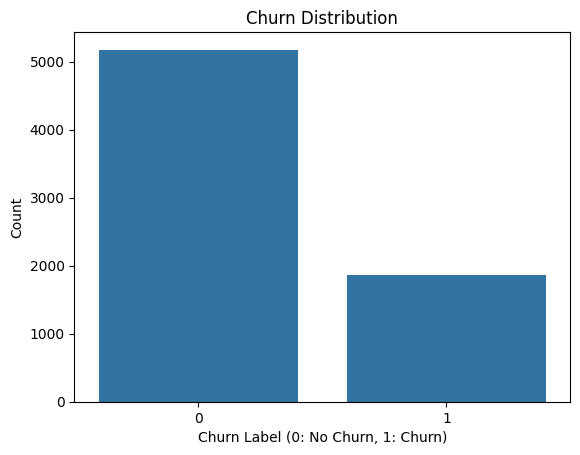

In [5]:
# ── 5. Exploratory Data Analysis (EDA) ───────────────────────

# Churn distribution
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn Label (0: No Churn, 1: Churn)')
plt.ylabel('Count')
plt.show()

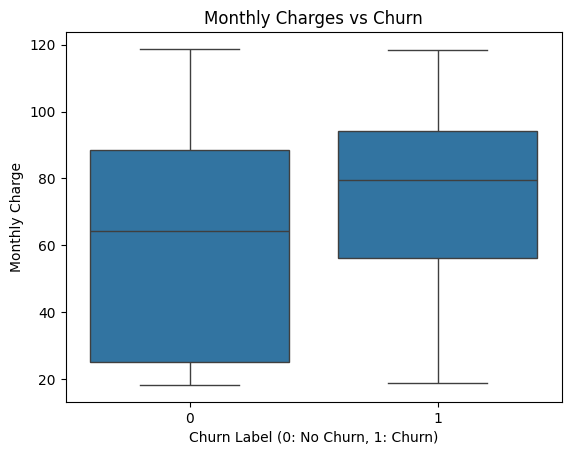

In [6]:
# Monthly charges vs churn
sns.boxplot(x='Churn Label', y='Monthly Charge', data=df.dropna(subset=['Churn Label', 'Monthly Charge']))
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn Label (0: No Churn, 1: Churn)')
plt.ylabel('Monthly Charge')
plt.show()

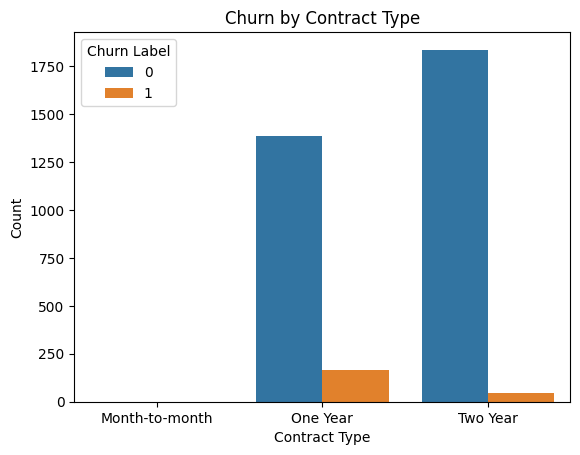

In [7]:
# Churn by Contract Type (using original column before encoding)
if 'Contract' in df.columns:
    sns.countplot(x='Contract', hue='Churn Label', data=df,
                  order=['Month-to-month', 'One Year', 'Two Year'])
    plt.title('Churn by Contract Type')
    plt.xlabel('Contract Type')
    plt.ylabel('Count')
    plt.show()

In [8]:
# ── 6. Feature Engineering ───────────────────────────────────

# Drop ID column, then one-hot encode all remaining categoricals
df = df.drop(columns=['Customer ID'], errors='ignore')
df = pd.get_dummies(df, drop_first=True)

print(f'DataFrame shape after encoding: {df.shape}')

DataFrame shape after encoding: (7043, 1157)


In [9]:
# ── 7. Train-Test Split ──────────────────────────────────────
from sklearn.model_selection import train_test_split

df_model = df.dropna(subset=['Churn Label'])

X = df_model.drop('Churn Label', axis=1)
y = df_model['Churn Label']

In [10]:
# Impute any residual NaNs in features
if X.isnull().sum().sum() > 0:
    print(f"Imputing {X.isnull().sum().sum()} NaNs in features with column mean.")
    X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (5634, 1156) | X_test: (1409, 1156)
y_train: (5634,) | y_test: (1409,)


In [11]:
# ── 8. Model Building — Logistic Regression ──────────────────

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9226

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1009
           1       0.87      0.85      0.86       400

    accuracy                           0.92      1409
   macro avg       0.91      0.90      0.90      1409
weighted avg       0.92      0.92      0.92      1409



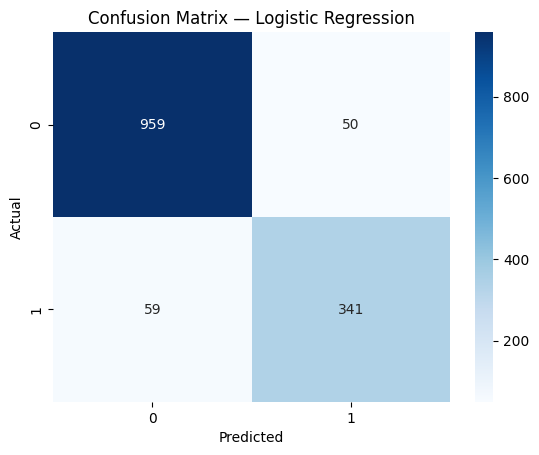

In [12]:
# ── 9. Model Evaluation ──────────────────────────────────────

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Random Forest Accuracy: 0.9922

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1009
           1       1.00      0.97      0.99       400

    accuracy                           0.99      1409
   macro avg       0.99      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409



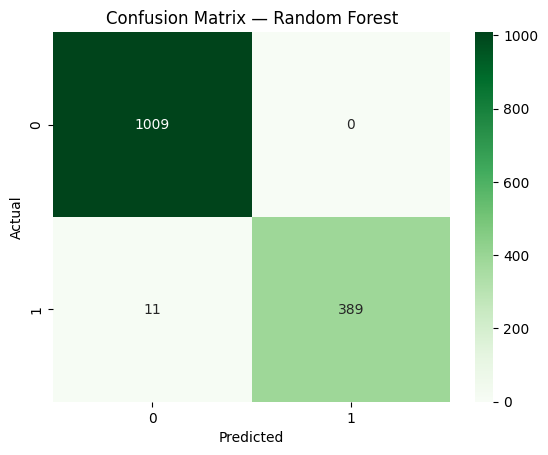

In [13]:
# ── 10. Better Model — Random Forest ─────────────────────────

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

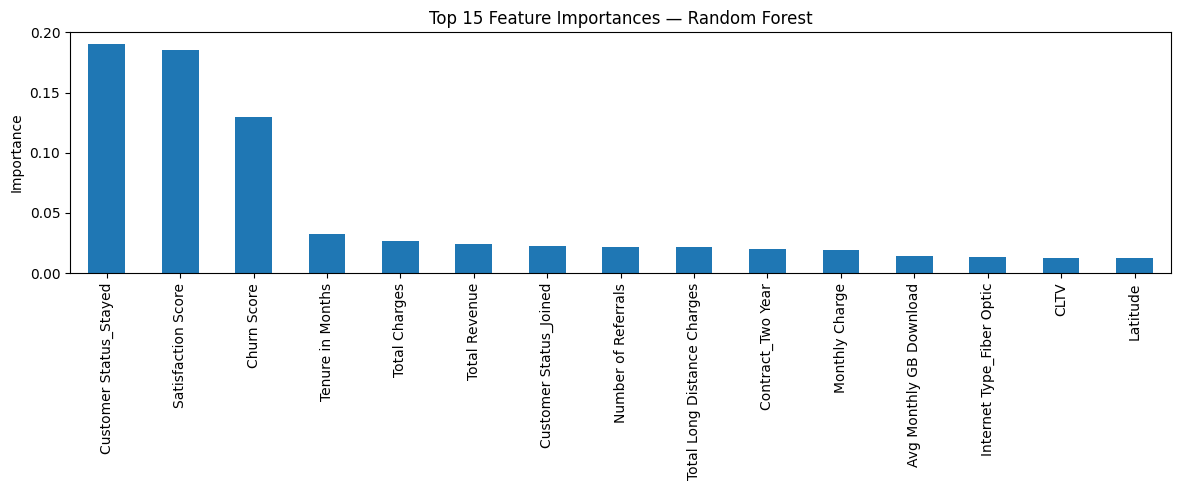

In [14]:
# ── 11. Feature Importance ───────────────────────────────────

importances = rf.feature_importances_
feat_df = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)

feat_df.plot(kind='bar', figsize=(12, 5))
plt.title('Top 15 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()